In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import welch
from scipy.signal.windows import tukey
from multiprocessing import get_context, cpu_count

import corner

%matplotlib inline
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['figure.dpi'] = 100

CHANNEL_NAMES = ['X', 'Y', 'Z']
CHANNEL_COLORS = ['k', 'r--', 'y']
np.random.seed(11_07_1993)

# Noise models PSD/CSD

In [9]:
class Config:


    # --- Observation / sampling ---
    f_min     = 2.5e-5   # Hz
    f_max     = 1.0e-1   # Hz
    T_OBS     = 1.0 / f_min          # seconds
    DT        = 1.0 / (2 * f_max)    # seconds
    SIDEREAL_YEAR = 365.25636 * 86400  # seconds

    # --- Physical constants ---
    C          = 299_792_458.0   # m/s
    WAVELENGTH = 1064.5e-9       # m

    # --- Noise / prior ---
    AVERAGE_ARMLENGTH    = 8.322688660167833   # light-seconds
    PARAM_NOISE_AMP   = np.array([2.4e-15, 6.35e-12])
    PARAM_INDICES_TO_FIT = [0, 1]
    PRIOR_FACTOR  = 1e2    # era 1e9 → troppo largo
    INIT_SPREAD   = 0.1    # era 0.01 → troppo stretto


print('Configuration loaded.')
print(f'  T_obs = {Config.T_OBS / Config.SIDEREAL_YEAR:.2f} yr')
print(f'  dt    = {Config.DT} s')
print(f'  f_min = {Config.f_min:.2e} Hz,  f_max = {Config.f_max:.2e} Hz')

Configuration loaded.
  T_obs = 0.00 yr
  dt    = 5.0 s
  f_min = 2.50e-05 Hz,  f_max = 1.00e-01 Hz


## The two free parameters are:
- `acc_level` – test-mass acceleration noise amplitude
- `readout_isi` – ISI readout noise amplitude

These enter the TDI X auto-PSD (`psd_xx`) and cross-PSD (`csd_xy`) between any pair of channels.

In [10]:
def compute_noise_psd_csd(freq, acc_level, readout_isi, armlength):
    """Return (psd_xx, csd_xy) for TDI X/Y/Z channels."""
    omega = 2 * np.pi * freq
    T     = armlength
    nu0   = Config.C / Config.WAVELENGTH

    disp_2_ffd = (omega / Config.WAVELENGTH / nu0) ** 2
    acc_2_ffd  = (1 / (Config.WAVELENGTH * omega) / nu0) ** 2

    tm_noise       = acc_level   ** 2 * (1 + (0.4e-3 / freq) ** 2) * (1 + (freq / 8e-3) ** 4)
    readout_noise  = readout_isi ** 2 * (1 + (2e-3 / freq) ** 4)

    psd_xx = (256 * np.cos(2*np.pi*freq*T)**2 * np.sin(2*np.pi*freq*T)**4
              * ((3 + np.cos(2*T*2*np.pi*freq)) * acc_2_ffd * tm_noise
                 + disp_2_ffd * readout_noise))
    csd_xy = (-16 * np.sin(2*np.pi*freq*T) * np.sin(4*np.pi*freq*T)**3
              * (4 * acc_2_ffd * tm_noise + disp_2_ffd * readout_noise))
    return psd_xx, csd_xy


def build_csd_matrix(freqs, noise_params=None):
    """Build the (n_freqs, 3, 3) CSD matrix for the three TDI channels."""
    if noise_params is None:
        noise_params = Config.PARAM_NOISE_AMP
    psd, csd_cross = compute_noise_psd_csd(
        freqs,
        acc_level=noise_params[0],
        readout_isi=noise_params[1],
        armlength=Config.AVERAGE_ARMLENGTH,
    )
    n_freqs = len(freqs)
    mat = np.zeros((n_freqs, 3, 3), dtype=complex)
    for i in range(3):
        mat[:, i, i] = psd
    for (i, j) in [(0,1), (1,2), (0,2)]:
        mat[:, i, j] = mat[:, j, i] = csd_cross
    return mat

## Noise data generation 

In [11]:
def generate_correlated_noise_fft(freqs, N, dt, csd_matrix):
    """Draw correlated Gaussian noise in the frequency domain via Cholesky."""
    n_channels = csd_matrix.shape[1]
    n_freqs    = len(freqs)
    cov_fft    = csd_matrix * N / (2 * dt)
    L          = np.linalg.cholesky(cov_fft)
    z = (np.random.normal(0, 1/np.sqrt(2), (n_freqs, n_channels))
         + 1j * np.random.normal(0, 1/np.sqrt(2), (n_freqs, n_channels)))
    return np.einsum('fij,fj->fi', L, z)

In [13]:
# Build time/frequency grids
N          = int(Config.T_OBS / Config.DT)
Config.T_OBS = Config.DT * N          # snap to exact grid
t          = np.arange(N) * Config.DT
freqs      = np.fft.rfftfreq(N, Config.DT)
freqs[0]   = freqs[1]                 # avoid DC singularity

print(f'N = {N} samples,  T_obs = {Config.T_OBS / Config.SIDEREAL_YEAR:.2f} yr')
print(f'n_freqs = {len(freqs)},  freq range = [{freqs[1]:.2e}, {freqs[-1]:.2e}] Hz')

# Generate clean (gap-free) data
csd_matrix     = build_csd_matrix(freqs)
fft_data_no_gaps = generate_correlated_noise_fft(freqs, N, Config.DT, csd_matrix)
time_data_no_gaps = np.fft.irfft(fft_data_no_gaps, n=N, axis=0)

print(f'fft_data_no_gaps shape: {fft_data_no_gaps.shape}')

N = 8000 samples,  T_obs = 0.00 yr
n_freqs = 4001,  freq range = [2.50e-05, 1.00e-01] Hz
fft_data_no_gaps shape: (4001, 3)


## Noise model PSD vs. simulated data

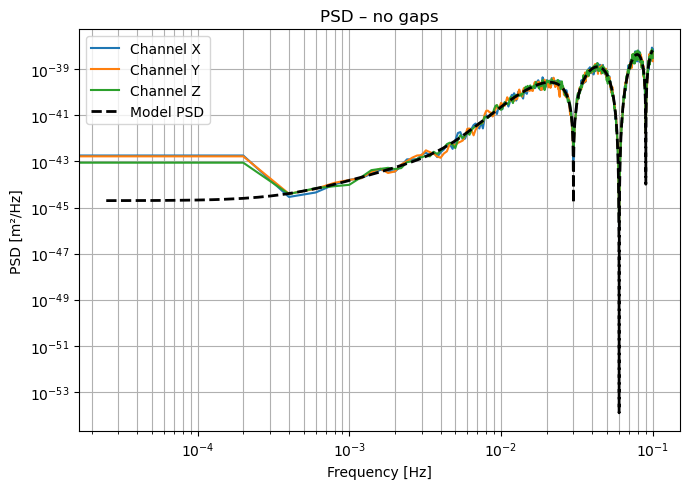

In [14]:
psd_model, _ = compute_noise_psd_csd(
    freqs,
    acc_level=Config.PARAM_NOISE_AMP[0],
    readout_isi=Config.PARAM_NOISE_AMP[1],
    armlength=Config.AVERAGE_ARMLENGTH,
)

fig, ax = plt.subplots()
for i, (name, ls) in enumerate(zip(CHANNEL_NAMES, ['C0', 'C1', 'C2'])):
    f_w, psd_w = signal.welch(time_data_no_gaps[:, i], fs=1/Config.DT,
                              nperseg=1000, scaling='density')
    ax.loglog(f_w, psd_w, color=ls, label=f'Channel {name}')
ax.loglog(freqs, psd_model, 'k--', lw=2, label='Model PSD')
ax.set(xlabel='Frequency [Hz]', ylabel='PSD [m²/Hz]',
       title='PSD – no gaps')
ax.grid(True, which='both')
ax.legend()
plt.tight_layout()
plt.show()